In [7]:
#import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.metrics import confusion_matrix

In [8]:
#plant generation and sensor Data Loading
plant1_gen = pd.read_csv(r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Solar Power Generation Data\Plant_1_Generation_Data.csv")
plant2_gen = pd.read_csv(r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Solar Power Generation Data\Plant_2_Generation_Data.csv")
plant1_sensor = pd.read_csv(r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Solar Power Generation Data\Plant_1_Weather_Sensor_Data.csv")
plant2_sensor = pd.read_csv(r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Solar Power Generation Data\Plant_2_Weather_Sensor_Data.csv")

<H3>Exploratory Analysis</H3>

In [9]:
plant1_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [10]:
plant2_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [11]:
print(plant1_gen.info())
print("_____"*20)
print(plant2_gen.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB
None
____________________________________________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  object 
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  object 
 3   DC_POWER     67698 non-

In [12]:
#Concatenating the Data
plant_gen = pd.concat([plant1_gen, plant2_gen], ignore_index=True)
print(f"There are {plant_gen ["SOURCE_KEY"].nunique()} inverters for both plants")
print(plant_gen.info())

There are 44 inverters for both plants
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136476 entries, 0 to 136475
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATE_TIME    136476 non-null  object 
 1   PLANT_ID     136476 non-null  int64  
 2   SOURCE_KEY   136476 non-null  object 
 3   DC_POWER     136476 non-null  float64
 4   AC_POWER     136476 non-null  float64
 5   DAILY_YIELD  136476 non-null  float64
 6   TOTAL_YIELD  136476 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 7.3+ MB
None


In [13]:
plant_gen.iloc[68779]

DATE_TIME      2020-05-15 00:00:00
PLANT_ID                   4136001
SOURCE_KEY         81aHJ1q11NBPMrL
DC_POWER                       0.0
AC_POWER                       0.0
DAILY_YIELD                    0.0
TOTAL_YIELD           1215278736.0
Name: 68779, dtype: object

In [14]:
#Standardizing the Date_time Column of the plant_gen data
plant_gen["DATE_TIME"] = pd.to_datetime(plant_gen["DATE_TIME"], format='mixed', dayfirst=True)
plant_gen["PLANT_ID"] = plant_gen["PLANT_ID"].astype("str")

In [15]:
#Checking to see data pattern
print(f"There are {plant_gen ["SOURCE_KEY"].nunique()} inverters for both plants")

There are 44 inverters for both plants


In [16]:
plant_genn= plant_gen.groupby(["DATE_TIME", "PLANT_ID"]).agg({"DC_POWER" : "sum",
  "AC_POWER" : "sum", 
  "DAILY_YIELD" :"sum",
  "TOTAL_YIELD" : "sum"}
).reset_index()

In [17]:
plant_genn.tail()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
6412,2020-06-17 23:15:00,4136001,0.0,0.0,93040.000000,1.419408e+10
6413,2020-06-17 23:30:00,4135001,0.0,0.0,129571.000000,1.561428e+08
6414,2020-06-17 23:30:00,4136001,0.0,0.0,93040.000000,1.419408e+10
6415,2020-06-17 23:45:00,4135001,0.0,0.0,127962.767857,1.561428e+08
6416,2020-06-17 23:45:00,4136001,0.0,0.0,93040.000000,1.419408e+10


In [18]:
print(plant_gen.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136476 entries, 0 to 136475
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   DATE_TIME    136476 non-null  datetime64[ns]
 1   PLANT_ID     136476 non-null  object        
 2   SOURCE_KEY   136476 non-null  object        
 3   DC_POWER     136476 non-null  float64       
 4   AC_POWER     136476 non-null  float64       
 5   DAILY_YIELD  136476 non-null  float64       
 6   TOTAL_YIELD  136476 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 7.3+ MB
None


<b>Sensor Data Combination and Cleaning</b>

In [19]:
plant1_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [20]:
plant1_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [21]:
print(plant1_sensor.info())
print("_____"*20)
print(plant2_sensor.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB
None
____________________________________________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3259 non-null   object 
 1   PLANT_ID             3259 non-null   int64  
 2   SOURCE_KEY   

In [22]:
#Conating the sensor data for both plants
plant_sensor = pd.concat([plant1_sensor, plant2_sensor],ignore_index=True)
plant_sensor["DATE_TIME"] = pd.to_datetime(plant_sensor["DATE_TIME"], format='mixed', dayfirst=True)
plant_sensor["PLANT_ID"] = plant_sensor["PLANT_ID"].astype("str")
plant_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [23]:
plant_sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6441 entries, 0 to 6440
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            6441 non-null   datetime64[ns]
 1   PLANT_ID             6441 non-null   object        
 2   SOURCE_KEY           6441 non-null   object        
 3   AMBIENT_TEMPERATURE  6441 non-null   float64       
 4   MODULE_TEMPERATURE   6441 non-null   float64       
 5   IRRADIATION          6441 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 302.1+ KB


In [24]:
#Merging the Generation and sensor data 
plant_data = pd.merge(left = plant_genn, right = plant_sensor, how="inner", on=["DATE_TIME", "PLANT_ID"])

In [25]:
plant_data.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.000000,1.435817e+08,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095,1.418960e+10,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
2,2020-05-15 00:15:00,4135001,0.0,0.0,0.000000,1.435817e+08,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
3,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000,1.418960e+10,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
4,2020-05-15 00:30:00,4135001,0.0,0.0,0.000000,1.435817e+08,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0


In [26]:
plant_data.drop(columns=["SOURCE_KEY"], inplace=True )

In [27]:
plant_data.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095,1.418960e+10,27.004764,25.060789,0.0
2,2020-05-15 00:15:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.084589,22.761668,0.0
3,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000,1.418960e+10,26.880811,24.421869,0.0
4,2020-05-15 00:30:00,4135001,0.0,0.0,0.000000,1.435817e+08,24.935753,22.592306,0.0


In [28]:
plant_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6416 entries, 0 to 6415
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            6416 non-null   datetime64[ns]
 1   PLANT_ID             6416 non-null   object        
 2   DC_POWER             6416 non-null   float64       
 3   AC_POWER             6416 non-null   float64       
 4   DAILY_YIELD          6416 non-null   float64       
 5   TOTAL_YIELD          6416 non-null   float64       
 6   AMBIENT_TEMPERATURE  6416 non-null   float64       
 7   MODULE_TEMPERATURE   6416 non-null   float64       
 8   IRRADIATION          6416 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 451.3+ KB


<h3>PREPROCESSING</h3>

In [29]:
#Splitting the datetime
plant_data['hour']= plant_data['DATE_TIME'].dt.hour
plant_data['day'] = plant_data['DATE_TIME'].dt.day
plant_data.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.184316,22.857507,0.0,0,15
1,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095,1.418960e+10,27.004764,25.060789,0.0,0,15
2,2020-05-15 00:15:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.084589,22.761668,0.0,0,15
3,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000,1.418960e+10,26.880811,24.421869,0.0,0,15
4,2020-05-15 00:30:00,4135001,0.0,0.0,0.000000,1.435817e+08,24.935753,22.592306,0.0,0,15


In [30]:
#checking the correlation of our data using a heatmap
correlation = plant_data.corr(numeric_only=True)
correlation

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day
DC_POWER,1.000000,0.797230,0.074614,-0.451639,0.271066,0.629020,0.650191,0.016987,0.015041
AC_POWER,0.797230,1.000000,0.023250,-0.108939,0.593164,0.903046,0.938184,0.026724,0.029328
DAILY_YIELD,0.074614,0.023250,1.000000,-0.014226,0.391752,0.137225,-0.015725,0.803312,-0.001577
TOTAL_YIELD,-0.451639,-0.108939,-0.014226,1.000000,0.297951,0.047750,-0.015027,-0.008224,-0.010362
AMBIENT_TEMPERATURE,0.271066,0.593164,0.391752,0.297951,1.000000,0.818020,0.654558,0.325898,0.239241
MODULE_TEMPERATURE,0.629020,0.903046,0.137225,0.047750,0.818020,1.000000,0.950708,0.127425,0.121287
IRRADIATION,0.650191,0.938184,-0.015725,-0.015027,0.654558,0.950708,1.000000,0.019722,0.051057
hour,0.016987,0.026724,0.803312,-0.008224,0.325898,0.127425,0.019722,1.000000,0.008826
day,0.015041,0.029328,-0.001577,-0.010362,0.239241,0.121287,0.051057,0.008826,1.000000


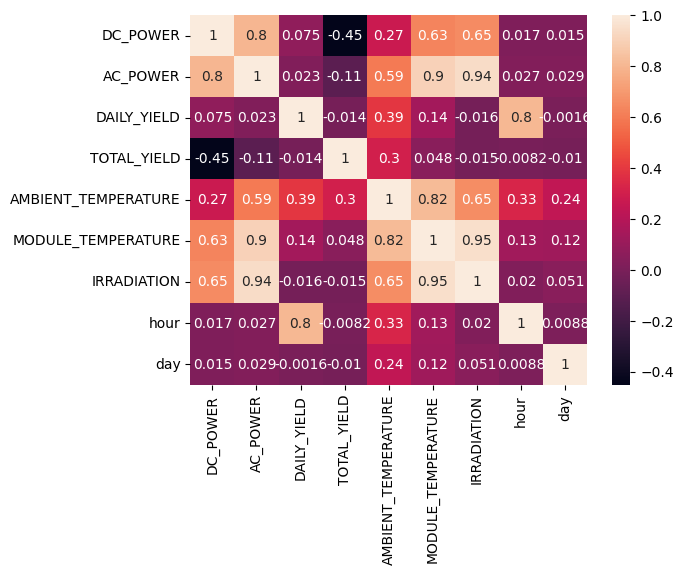

In [31]:
correlation = plant_data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True);

<h4>Encoding and standardizing data</h4>

In [32]:
#Encoding the plant_id since it's an object
encoder = OneHotEncoder(sparse_output=False)
plant_id_encoded = encoder.fit_transform(plant_data[["PLANT_ID"]])

In [33]:
#Turn encoded plant_id into a data frame and add to the plant_data dataframe
plant_id_df = pd.DataFrame(plant_id_encoded, columns=encoder.get_feature_names_out(["PLANT_ID"]))
plant_data_encoded = pd.concat([plant_data.reset_index(drop=True), plant_id_df], axis=1)
plant_data_encoded.head()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day,PLANT_ID_4135001,PLANT_ID_4136001
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.184316,22.857507,0.0,0,15,1.0,0.0
1,2020-05-15 00:00:00,4136001,0.0,0.0,48899.938095,1.418960e+10,27.004764,25.060789,0.0,0,15,0.0,1.0
2,2020-05-15 00:15:00,4135001,0.0,0.0,0.000000,1.435817e+08,25.084589,22.761668,0.0,0,15,1.0,0.0
3,2020-05-15 00:15:00,4136001,0.0,0.0,28401.000000,1.418960e+10,26.880811,24.421869,0.0,0,15,0.0,1.0
4,2020-05-15 00:30:00,4135001,0.0,0.0,0.000000,1.435817e+08,24.935753,22.592306,0.0,0,15,1.0,0.0


In [34]:
plant_data_encoded.drop(columns=['PLANT_ID'], inplace=True)

In [35]:
plant_data_encoded.tail()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,day,PLANT_ID_4135001,PLANT_ID_4136001
6411,2020-06-17 23:15:00,0.0,0.0,93040.000000,1.419408e+10,23.354743,22.492245,0.0,23,17,0.0,1.0
6412,2020-06-17 23:30:00,0.0,0.0,129571.000000,1.561428e+08,21.969495,20.734963,0.0,23,17,1.0,0.0
6413,2020-06-17 23:30:00,0.0,0.0,93040.000000,1.419408e+10,23.291048,22.373909,0.0,23,17,0.0,1.0
6414,2020-06-17 23:45:00,0.0,0.0,127962.767857,1.561428e+08,21.909288,20.427972,0.0,23,17,1.0,0.0
6415,2020-06-17 23:45:00,0.0,0.0,93040.000000,1.419408e+10,23.202871,22.535908,0.0,23,17,0.0,1.0


In [36]:
plant_data[['AC_POWER']].describe()

,AC_POWER
count,6416.000000
mean,5844.946416
std,7576.958173
min,0.000000
25%,0.000000
50%,638.473810
75%,11898.456667
max,29150.212499


<h3>DATA SPLITTING</h3>

In [37]:
#Getting the number of Unique days
start_date = plant_data_encoded['DATE_TIME'].min()
end_date = plant_data_encoded['DATE_TIME'].max()
total_days_excluding_start_date = (end_date - start_date).days
total_days = total_days_excluding_start_date + 1
print(f"There are {total_days} days")

There are 34 days


In [59]:
#splitting the datetime 
split_days = int(total_days * 0.8)
split_date = start_date + pd.Timedelta(days=split_days)

print(f"The 80% split date is: {split_date}")

The 80% split date is: 2020-06-11 00:00:00


In [48]:
#Splitting the Data into test and train data
train_data = plant_data_encoded[plant_data_encoded['DATE_TIME'] < split_date]
test_data = plant_data_encoded[plant_data_encoded['DATE_TIME'] >= split_date]

In [49]:
#Features and target
features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "hour", "PLANT_ID_4135001", "PLANT_ID_4136001"]
target = "AC_POWER"

In [50]:
plant_data_encoded.columns

Index(['DATE_TIME', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
       'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour',
       'day', 'PLANT_ID_4135001', 'PLANT_ID_4136001'],
      dtype='object')

In [51]:
X_train = train_data[features]
X_test = test_data[features]
y_train = train_data[target]
y_test = test_data[target]

In [52]:
#Initializing the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [53]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = model.predict(X_test)

In [55]:
#metrics and mean error calculation
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"Random Forest RMSE: {root_mean_squared_error(y_test, y_pred)}")

Random Forest R2 Score: 0.9658531337542368
Random Forest MAE: 450.12660010111375
Random Forest RMSE: 1259.550020149947


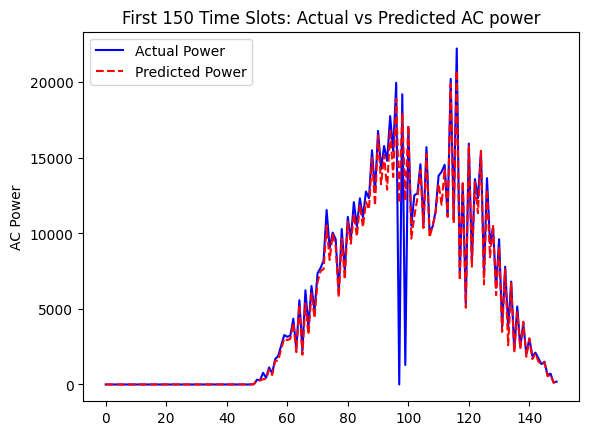

In [56]:
plt.plot(y_test.values[:150], label='Actual Power', color='blue')
plt.plot(y_pred[:150], label='Predicted Power', color='red', linestyle='--')
plt.title('First 150 Time Slots: Actual vs Predicted AC power')
plt.ylabel('AC Power')
plt.legend()
plt.show()

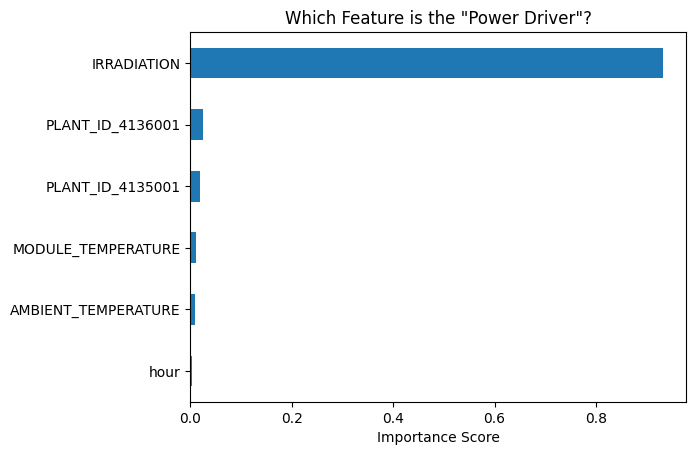

In [57]:
# Importances and Features
importances = model.feature_importances_
feature_names = features # The list we defined earlier

# Create a Series for easy plotting
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

feature_importance_df.plot(kind='barh')
plt.title('Which Feature is the "Power Driver"?')
plt.xlabel('Importance Score')
plt.show()